In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import kagglehub

c:\Users\Emilien JEMELEN\Documents\SGR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

In [3]:
# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Emilien JEMELEN\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1


In [4]:
diabetes_ds = pd.read_csv('C:/Users/Emilien JEMELEN/Documents/diabetes.csv')
diabetes_ds.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
diabetes_ds.shape

(768, 9)

In [6]:
print('Proportion of 1s:', np.round(diabetes_ds.Outcome.sum()/diabetes_ds.shape[0],2))

Proportion of 1s: 0.35


#### some preprocessing

In [7]:
features = diabetes_ds.drop(['Outcome'], axis=1)
# missing values mean imputation
features = features.fillna(features.mean(numeric_only=True))
features.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [8]:
X = features
Y = diabetes_ds.Outcome

In [9]:
# split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=42, stratify=Y)

## <font color='yellow'> logistic regression

In [10]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       300
           1       0.63      0.58      0.61       161

    accuracy                           0.74       461
   macro avg       0.71      0.70      0.70       461
weighted avg       0.73      0.74      0.73       461

Test Accuracy: 0.735357917570499


### Retrieving $\kappa_f$ confidence function

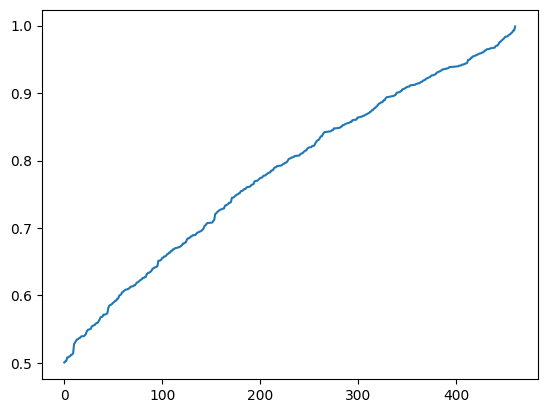

In [12]:
y_true = Y_test
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [13]:
sgr_df = pd.DataFrame({'y_true': y_true,
              'y_pred': y_pred,
              'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
473,0,0,0.500446
293,1,0,0.502096
199,1,0,0.502561
560,1,0,0.507841
298,1,1,0.507906
...,...,...,...
494,0,0,0.988874
502,1,0,0.990137
81,0,0,0.992580
349,1,0,0.992978


In [14]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

## <font color='yellow'> SVM classifier (linear kernel)

In [15]:
model = SVC(kernel='linear', C=1.0, probability=True)  # C is the regularization parameter
model.fit(X_train, Y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
# Predict and evaluate
Y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

Accuracy: 0.7483731019522777
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       300
           1       0.67      0.56      0.61       161

    accuracy                           0.75       461
   macro avg       0.72      0.70      0.71       461
weighted avg       0.74      0.75      0.74       461



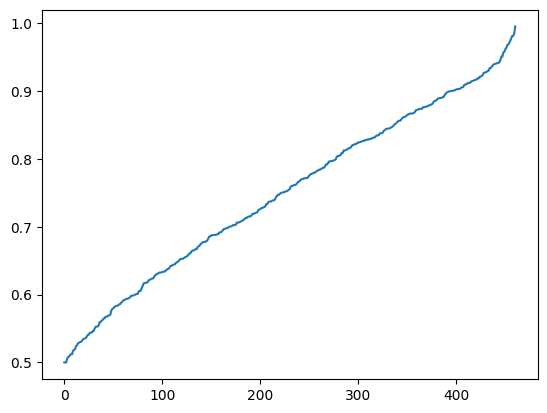

In [17]:
kappa = model.predict_proba(X_test).max(axis=1)
plt.plot(sorted(kappa))

In [18]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': Y_pred,
                       'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
648,1,0,0.500000
345,0,1,0.500000
267,0,1,0.500000
517,0,0,0.505976
246,0,0,0.508075
...,...,...,...
537,0,0,0.977975
81,0,0,0.981520
502,1,0,0.981713
349,1,0,0.984398


In [19]:
pickle.dump(sgr_df, open('sgr_set_svm','wb'))

## <font color='yellow'> MLP

In [ ]:
# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

# Define  small MLP 
class SmallMLP(nn.Module):
    def __init__(self, input_dim):
        super(SmallMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
input_dim = X_train_tensor.shape[1]
model = SmallMLP(input_dim)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Optional: Evaluate on test set
    if epoch % 10 == 0 or epoch == epochs - 1:
        model.eval()
        with torch.no_grad():
            test_preds = model(X_test_tensor)
            test_preds_binary = (test_preds > 0.5).float()
            test_acc = (test_preds_binary == Y_test_tensor).float().mean().item()
            print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch 0 | Loss: 0.6769 | Test Acc: 64.21%
Epoch 10 | Loss: 0.6095 | Test Acc: 65.08%
Epoch 20 | Loss: 0.5427 | Test Acc: 66.81%
Epoch 30 | Loss: 0.4883 | Test Acc: 72.23%
Epoch 40 | Loss: 0.4531 | Test Acc: 73.10%
Epoch 50 | Loss: 0.4377 | Test Acc: 73.10%
Epoch 60 | Loss: 0.4287 | Test Acc: 73.97%
Epoch 70 | Loss: 0.4197 | Test Acc: 73.75%
Epoch 80 | Loss: 0.4110 | Test Acc: 73.97%
Epoch 90 | Loss: 0.4022 | Test Acc: 74.62%
Epoch 99 | Loss: 0.3957 | Test Acc: 75.49%


In [24]:
model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor)  # Shape: (num_samples, 1)
    test_preds = (test_probs > 0.5).float() 

In [26]:
sgr_df = pd.DataFrame({'y_true': Y_test,
                       'y_pred': test_preds.numpy().astype(int).flatten(),
                       'kappa': test_probs.numpy().flatten()}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
75,0,0,0.000101
680,0,0,0.002103
349,1,0,0.002135
273,0,0,0.003015
617,0,0,0.003310
...,...,...,...
120,1,1,0.965230
332,1,1,0.968916
440,1,1,0.970861
579,1,1,0.977817


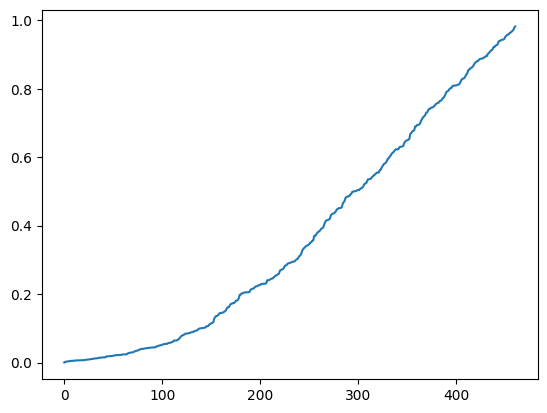

In [28]:
plt.plot(sorted(sgr_df.kappa))
plt.show()

In [29]:
pickle.dump(sgr_df, open('sgr_set_mlp', 'wb'))